In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os

# Testing how the audio file look

In [2]:
y,sampling_rate = librosa.load("./archive/Actor_01/03-01-01-01-01-01-01.wav")
sampling_rate

/home/abhisekmohapata/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


22050

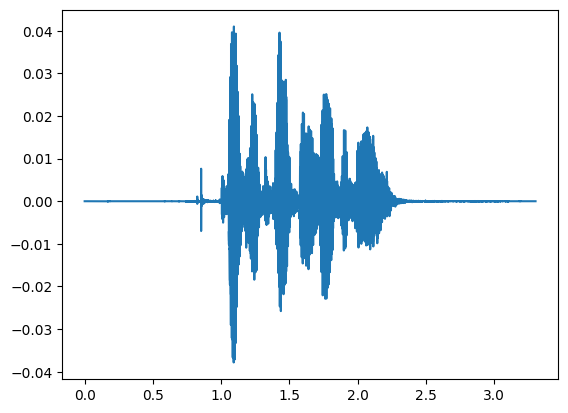

In [3]:
t = np.linspace(0,len(y)/sampling_rate,len(y))

plt.plot(t,y)

### Importing all audio files (in time domain)

In [4]:
# Loading the data in time domain

folders = [i for i in os.listdir("./archive/") if i[:5] == "Actor"]
audio_files = []
true_labels = []
for i in folders:
    folder = os.path.join("./archive/",i)
    files = os.listdir(folder)
    for f in files:
        y,sr = librosa.load(os.path.join(folder,f))
        true_labels.append(int(f[6:8]))
        if sr != sampling_rate:
            print(f"All don't have same sampling rate. {sr} != {sampling_rate}")
        audio_files.append(y)



Text(0.5, 1.0, 'Distribution of diffent classes of emotions')

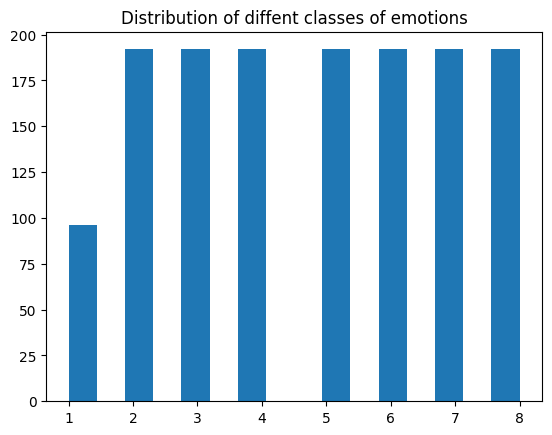

In [5]:
plt.hist(true_labels,bins = 16)
plt.title("Distribution of diffent classes of emotions")

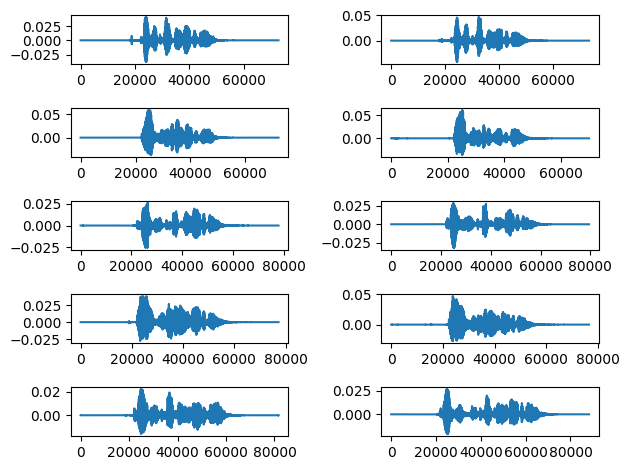

In [6]:
n = 10
for i in range(n):
    plt.subplot(5,2,i+1)
    plt.plot(audio_files[i])
    plt.tight_layout()

I tried to remove the empty part of the audio but not removing it mostly gave similar result. Moreover, it helped in avoiding overfitting

3


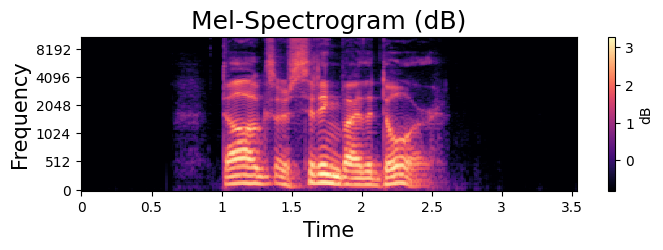

In [7]:
i = 14
print(true_labels[i])
n_fft = 1024
hop_length = 256

mel_signal = librosa.feature.melspectrogram(y=audio_files[i], sr=sampling_rate, hop_length=hop_length, 
 n_fft=n_fft)
power_to_db = librosa.power_to_db(mel_signal, ref=np.max)
#mfccs = librosa.feature.mfcc(S=power_to_db, n_mfcc=64)
power_to_db -= power_to_db.mean()
power_to_db /= power_to_db.std()
plt.figure(figsize=(8,2))
librosa.display.specshow(power_to_db, sr=sampling_rate, x_axis='time', y_axis='mel', hop_length=hop_length, cmap='magma')
plt.colorbar(label='dB')
plt.title('Mel-Spectrogram (dB)', fontdict=dict(size=18))
plt.xlabel('Time', fontdict=dict(size=15))
plt.ylabel('Frequency', fontdict=dict(size=15))
plt.show()

It is an mel-spectrogram (in log scale). The dark part is the empty space

In [8]:
audio_spectro = []
x = np.array([])

for audio in audio_files:
    mel_signal = librosa.feature.melspectrogram(y=audio, sr=sampling_rate, hop_length=hop_length, n_fft=n_fft)
    spectrogram = librosa.power_to_db(mel_signal, ref=np.max)
    #spectrogram = librosa.feature.mfcc(S=spectrogram, n_mfcc=64)
    spectrogram -= spectrogram.mean()
    spectrogram /= spectrogram.std()
    audio_spectro.append(spectrogram)

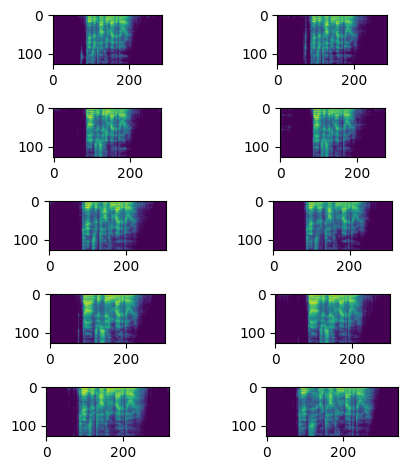

In [9]:
n = 10
for i in range(n):
    plt.subplot(5,2,i+1)
    plt.imshow(audio_spectro[i])
    plt.tight_layout()

## Implementing Audio CNN

below I have made the dataset for it

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader,random_split

In [11]:
from torchvision import transforms

class RAVDESSDataset(Dataset):
    def __init__(self,audio_files,labels,transform=transforms.Compose([
    transforms.Resize((64, 256))
]), target_transform=None):
        super().__init__()
        self.files = audio_files
        self.label = labels
        if len(self.label) != len(self.files):
            print("The two list are not equal in length")
        self.transform = transform
        self.target_transform = target_transform
        
        if self.transform:
            for i,image in enumerate(self.files):
                self.files[i] = self.transform(torch.tensor(image).reshape(1,128,-1))

        for i in range(len(self.label)):
            x = np.zeros(8,dtype = np.float32)
            x[int(self.label[i]) - 1] = 1.0
            self.label[i] = x
        
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        image,label = self.files[idx], self.label[idx]

        
        return image,label

In [12]:

dataset = RAVDESSDataset(audio_spectro.copy(),true_labels.copy())

print(len(dataset))

testing_set_frac = 0.2
valid_set_frac = 0.1

test_size = int(len(dataset)*testing_set_frac) 
valid_size = int(len(dataset)*valid_set_frac) 

train_size = len(dataset) - test_size - valid_size

train_dataset,valid_dataset, test_dataset = random_split(dataset, [train_size,valid_size, test_size],generator=torch.Generator().manual_seed(42))

1440


In [13]:
valid_data = torch.utils.data.DataLoader(valid_dataset,batch_size = 20)

In [14]:
class AudioCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1,
                       out_channels=16,
                       kernel_size=2,bias=True),
                torch.nn.Dropout(0.4),
            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=16,
                       out_channels=32,
                       kernel_size=2,bias=True),
                torch.nn.Dropout(0.4), 
            torch.nn.MaxPool2d(kernel_size = 2),
        )
        
        self.model2= torch.nn.Sequential(
            
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32,
                       out_channels=32,
                       kernel_size=2,bias=True),
                torch.nn.Dropout(0.4),      
            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d((16,16)),
            torch.nn.Flatten(),)
        
        self.model3= torch.nn.Sequential(
            torch.nn.Linear(32*16*16,32,bias=True),
            torch.nn.ReLU(),
            torch.nn.Linear(32,8,bias=True),
            #torch.nn.Softmax(1)
        )

    def forward(self,x):
        x1 = self.model1(x)
        x2 = self.model2(x1)
        x3 = self.model3(x2)
        return x3

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:
import time

learning_rate = 0.002
max_epochs = 70
epoch_int = 10
batch_size = 128


train_data = torch.utils.data.DataLoader(train_dataset,batch_size = batch_size)
total_size = len(train_data.dataset.dataset.files)

def CNNModelTrain(train_data,learning_rate = 0.0015,
    max_epochs = 70,
    epoch_int = 10,
    batch_size = 128,
):
    CNN_model = AudioCNN()
    CNN_model.to(device)
    
    
    
    
    lossfn = torch.nn.CrossEntropyLoss()
    optimiser = torch.optim.AdamW(CNN_model.parameters(),lr = learning_rate)
    
    training_loss = []
    accuracies = []
    start = time.time()
    for i in range(max_epochs):
        CNN_model.train()
        correct = 0
        loss_val = 0
        for batch, (X, y) in enumerate(train_data):
            optimiser.zero_grad()
            X = X.to(device)
            y = y.to(device)
    
            
            pred = CNN_model(X)
            loss = lossfn(pred, y)
            loss.backward()
            loss_val += loss.item()*batch_size/train_size
            optimiser.step()
    
            
            X = X.to("cpu")
            y = y.to("cpu")
            
            correct = 0
        with torch.no_grad():
                for images, labels in valid_data:
                    images = images.to(device)
                    outputs = CNN_model(images)
                    pred = torch.softmax(outputs, dim=1)
                    
                    preds = outputs.argmax(dim=1)
                    preds = preds.to("cpu")
                    images = images.to("cpu")
                    labels = labels.argmax(dim=1)
            
                    correct += (preds == labels).sum().item()
        training_loss.append(loss_val)
        
        accuracy = 100*correct/valid_size
        accuracies.append(accuracy)
        if i%epoch_int == 0 : 
            print(f"Epoch {i+1} training loss :{training_loss[-1]:9f} accuracy = {accuracy}%")
            print(time.time()-start,"s")
    return CNN_model, (accuracies, training_loss)

CNN_model, (accuracies, training_loss) = CNNModelTrain(train_data,learning_rate,max_epochs,epoch_int,batch_size)

CNN_param = (learning_rate,max_epochs,epoch_int,batch_size)

Epoch 1 training loss : 2.205371 accuracy = 15.972222222222221%
0.6461806297302246 s
Epoch 11 training loss : 1.184545 accuracy = 42.361111111111114%
4.3210413455963135 s
Epoch 21 training loss : 0.823142 accuracy = 56.25%
7.994511604309082 s
Epoch 31 training loss : 0.628237 accuracy = 56.94444444444444%
11.665482997894287 s
Epoch 41 training loss : 0.491443 accuracy = 61.111111111111114%
15.34559154510498 s
Epoch 51 training loss : 0.559900 accuracy = 54.166666666666664%
19.218944549560547 s
Epoch 61 training loss : 0.243088 accuracy = 67.36111111111111%
23.1149582862854 s


Text(0, 0.5, 'Loss')

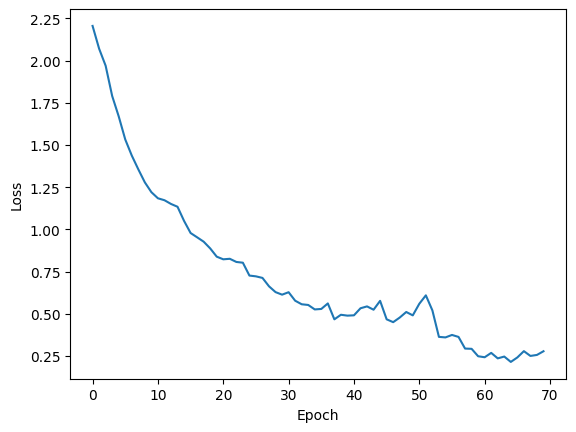

In [17]:
plt.plot(list(range(len(training_loss))),training_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")

Text(0, 0.5, 'accuracy(%)')

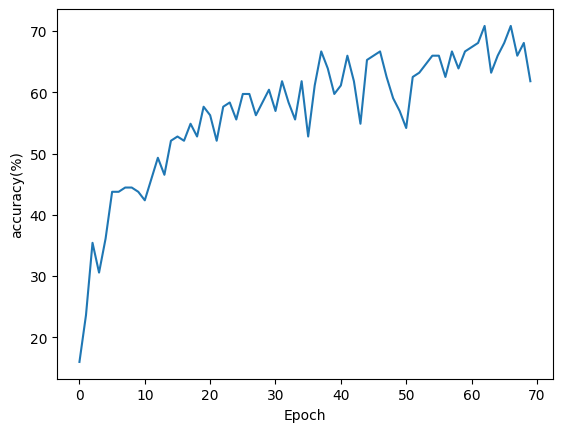

In [18]:
plt.plot(list(range(len(accuracies))),accuracies)
plt.xlabel("Epoch")
plt.ylabel("accuracy(%)")

In [19]:
test_data = torch.utils.data.DataLoader(test_dataset,batch_size = 64)

In [20]:
CNN_model.eval()
correct = 0
total = 0
coff_mat = np.zeros((8,8))
accuracies = []

with torch.no_grad():
    for images, labels in test_data:
        images = images.to(device)
        outputs = CNN_model(images)
        pred = torch.softmax(outputs, dim=1)
        
        preds = outputs.argmax(dim=1)
        preds = preds.to("cpu")
        labels = labels.argmax(dim=1)
        for i in range(len(preds)):
            coff_mat[preds[i],labels[i]]+=1

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        accuracies.append(correct/total*100)
        images = images.to("cpu")

CNN_model.to("cpu")

print("Test Accuracy:",100*correct/total,"%")


Test Accuracy: 58.68055555555556 %


Text(0, 0.5, 'accuracy(%)')

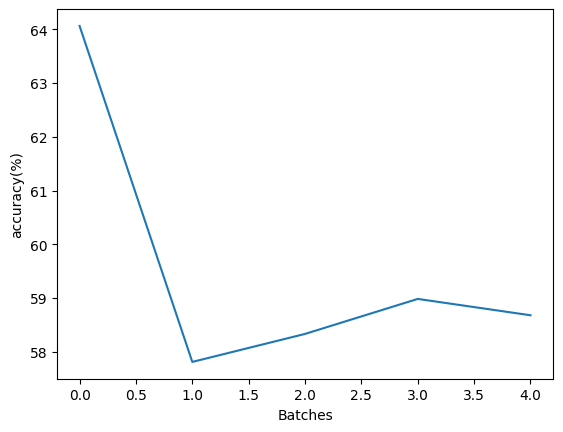

In [21]:
plt.plot(list(range(len(accuracies))),accuracies)
plt.xlabel("Batches")
plt.ylabel("accuracy(%)")

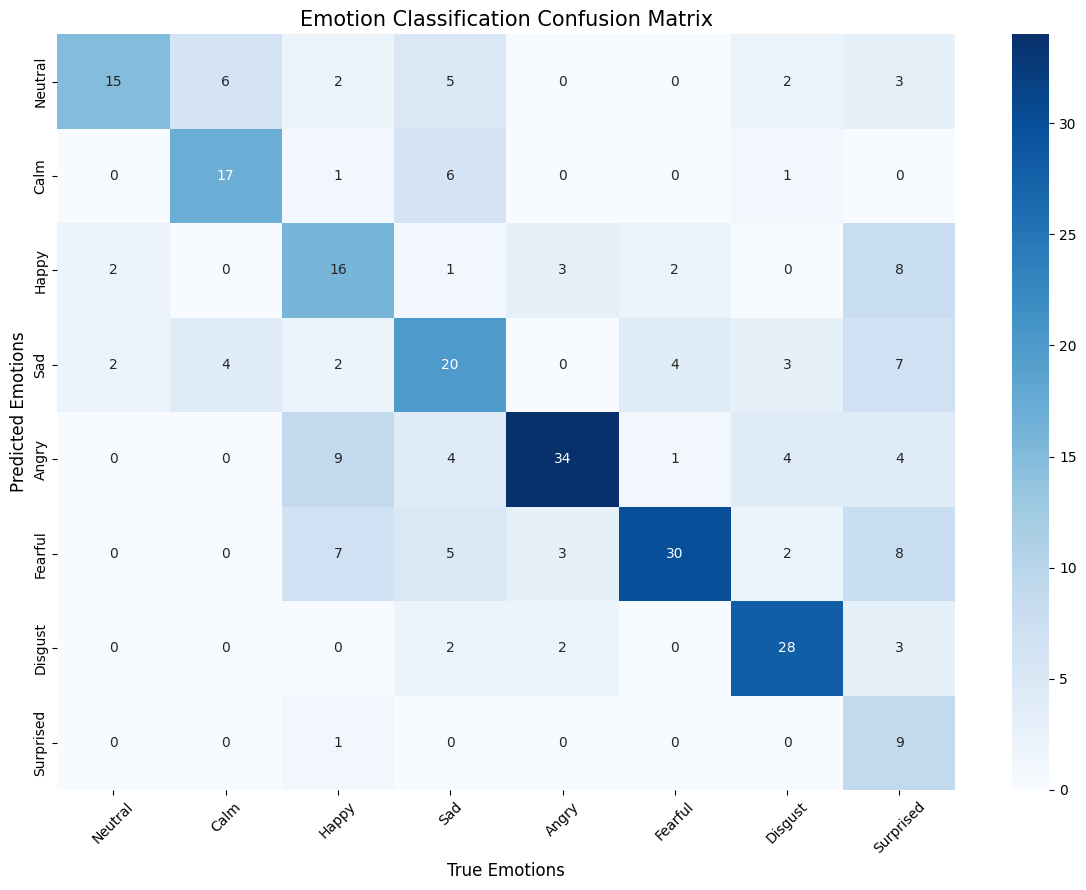

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

emotion_labels = [
    "Neutral", "Calm", "Happy", "Sad", 
    "Angry", "Fearful", "Disgust", "Surprised"
]

plt.figure(figsize=(12, 9))

sns.heatmap(coff_mat, annot=True, fmt='g', cmap='Blues', 
            xticklabels=emotion_labels, 
            yticklabels=emotion_labels)

plt.xlabel('True Emotions', fontsize=12)
plt.ylabel('Predicted Emotions', fontsize=12)
plt.title('Emotion Classification Confusion Matrix', fontsize=15)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It seems like suprised is mistaken for some other strong emotions

In [23]:
tp = np.diag(coff_mat)
fp = np.sum(coff_mat, axis=1) - tp  
fn = np.sum(coff_mat, axis=0) - tp  

epsilon = 1e-7
precision = tp / (tp + fp + epsilon)
recall = tp / (tp + fn + epsilon)
f1 = 2 * (precision * recall) / (precision + recall + epsilon)


macro_f1 = np.mean(f1)
accuracy = np.sum(tp) / np.sum(coff_mat)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Display per-class results
emotion_labels = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]
for i, label in enumerate(emotion_labels):
    print(f"{label}: Precision: {precision[i]:.2f} Recall: {recall[i]:.2f} F1: {f1[i]:.2f}")

Accuracy: 0.5868
Macro F1-Score: 0.5747
Neutral: Precision: 0.45 Recall: 0.79 F1: 0.58
Calm: Precision: 0.68 Recall: 0.63 F1: 0.65
Happy: Precision: 0.50 Recall: 0.42 F1: 0.46
Sad: Precision: 0.48 Recall: 0.47 F1: 0.47
Angry: Precision: 0.61 Recall: 0.81 F1: 0.69
Fearful: Precision: 0.55 Recall: 0.81 F1: 0.65
Disgust: Precision: 0.80 Recall: 0.70 F1: 0.75
Surprised: Precision: 0.90 Recall: 0.21 F1: 0.35


## Text RNN 

In [24]:
import whisper

model = whisper.load_model("base")


result = model.transcribe("./archive/Actor_01/03-01-01-01-01-01-01.wav")


print(result["text"])

 Kids are talking by the door.


I have used whisper base one and for embedding, I have used distilbert 

In [25]:
folders = os.listdir("./archive/")[:-1]

statements_whisper = []

from tqdm import tqdm


for i in tqdm(audio_files):
    res = model.transcribe(i)
    statements_whisper.append(res["text"])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1440/1440 [02:57<00:00,  8.10it/s]


In [26]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

transcription = "The Huck Dogs are sitting by the door."

inputs = tokenizer(
    transcription, 
    padding="max_length", 
    max_length=32, 
    truncation=True, 
    return_tensors="pt"
)

In [27]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer

class EmotionRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dime):
        super(EmotionRNN, self).__init__()
        
        # Word Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim)
            
        # Bidirectional LSTM: processes word embeddings sequentially
        self.lstm = nn.LSTM(embed_dim, 
                           hidden_dim, 
                           num_layers=2, 
                           bidirectional=True, 
                           dropout=0.3,
                           batch_first=True)
        
        # Fully connected layer (hidden_dim * 2 because it's bidirectional)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32,8),
        )
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, emb):
        # text shape: [batch_size, seq_length]
        embedded = self.dropout(self.embedding(emb))
        
        # output shape: [batch_size, seq_length, hidden_dim * 2]
        # hidden shape: [num_layers * 2, batch_size, hidden_dim]
        output, (hidden, cell) = self.lstm(embedded)
        
        # Concatenate the final forward and backward hidden states
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        return self.fc(self.dropout(hidden))

In [28]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def preprocess_text(text_list, max_length=64):
    encoded_input = tokenizer(
        text_list, 
        padding='max_length', 
        truncation=True, 
        max_length=max_length, 
        return_tensors='pt'
    )
    return encoded_input['input_ids']

input_tensor = preprocess_text(statements_whisper)
input_tensor.shape

torch.Size([1440, 64])

In [29]:
true_labels = list(torch.argmax(torch.Tensor(dataset.label),axis=1)+1)
input_labels = torch.Tensor(dataset.label.copy())

/tmp/ipykernel_519783/2033761960.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  true_labels = list(torch.argmax(torch.Tensor(dataset.label),axis=1)+1)


In [30]:
class RNNDataset(Dataset):
    def __init__(self,input_tensor,input_label):
        self.x = torch.Tensor(input_tensor)
        self.y = torch.Tensor(input_label)
    def __len__(self):
        return len(input_tensor)

    def __getitem__(self,i):
        return torch.Tensor(self.x[i]),torch.Tensor(self.y[i])

In [31]:
batches = 128

Rdataset = RNNDataset(input_tensor,input_labels)

valid_frac = 0.1
train_frac = 0.8
train_size = int(len(input_tensor)*train_frac)
valid_size = int(len(input_tensor)*valid_frac)
test_size = len(input_tensor)-train_size-valid_size


train_dataset,valid_dataset, test_dataset = random_split(Rdataset, [train_size,valid_size, test_size],generator=torch.Generator().manual_seed(42))

In [32]:
train_data = DataLoader(train_dataset,batch_size=batches)

In [33]:
# Hyperparameters
VOCAB_SIZE = tokenizer.vocab_size
EMBED_DIM = 300   # Standard for GloVe
HIDDEN_DIM = 64
OUTPUT_DIM = 8     # e.g., happy, sad, angry, fear, surprise, neutral
epoches = 25
def RNNModelTrain(train_data,VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM,lr,epoches,):
    RNNmodel = EmotionRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
    
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay= 0.1)
    loss_fn = nn.CrossEntropyLoss()
    
    # Dummy training step
    RNNmodel.train()
    accuracies = []
    for t in range(epoches):
        loss = 0
        correct = 0
        for (x,y) in train_data:
            y=y.to(device)
            x=x.to(device)
            preds = RNNmodel(x)
            
            loss = loss_fn(preds, y)
            loss.backward()
            optimiser.step()
    
            
            optimiser.zero_grad()
            preds = preds.argmax(axis=1)
            y2 = y.argmax(axis=1)
            correct += torch.sum(torch.where(preds == y2,1.,0.)).item()
            
            y=y.to("cpu")
            x=x.to("cpu")
        accuracies.append(correct/train_size)
        print(f"{t+1}th epoch Loss: {loss.item()} Accuracy :{correct/train_size}")

    return RNNmodel , (accuracies)

RNNmodel , (accuracies) = RNNModelTrain(train_data,VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM,0.0001,epoches)
RNN_param = (VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM,0.0001,epoches)

1th epoch Loss: 2.084386110305786 Accuracy :0.13194444444444445
2th epoch Loss: 2.0864737033843994 Accuracy :0.1345486111111111
3th epoch Loss: 2.084834337234497 Accuracy :0.125
4th epoch Loss: 2.085374116897583 Accuracy :0.13368055555555555
5th epoch Loss: 2.0871388912200928 Accuracy :0.11979166666666667
6th epoch Loss: 2.083641767501831 Accuracy :0.15104166666666666
7th epoch Loss: 2.0851235389709473 Accuracy :0.13541666666666666
8th epoch Loss: 2.0846290588378906 Accuracy :0.13541666666666666
9th epoch Loss: 2.084446430206299 Accuracy :0.14322916666666666
10th epoch Loss: 2.086193084716797 Accuracy :0.12586805555555555
11th epoch Loss: 2.0855627059936523 Accuracy :0.1267361111111111
12th epoch Loss: 2.087033987045288 Accuracy :0.1423611111111111
13th epoch Loss: 2.0833663940429688 Accuracy :0.1345486111111111
14th epoch Loss: 2.0854525566101074 Accuracy :0.11631944444444445
15th epoch Loss: 2.0854313373565674 Accuracy :0.12586805555555555
16th epoch Loss: 2.084890365600586 Accuracy 

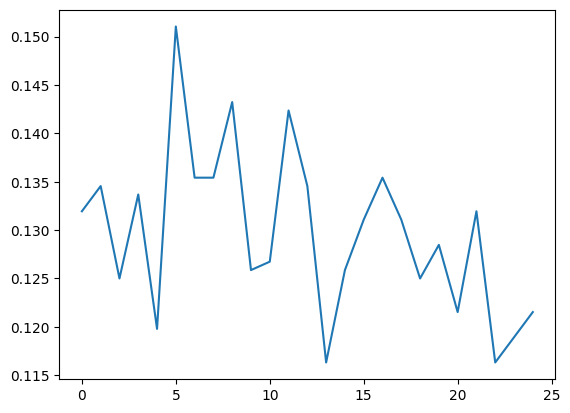

In [34]:
plt.plot(accuracies)

In [35]:
test_data = DataLoader(test_dataset,batch_size=batches)

In [36]:
RNNmodel.eval()
RNNmodel.to(device)
correct = 0
coff_mat = np.zeros((8,8))
for (x,y) in test_data:
    y=y.to(device)
    x=x.to(device)
    preds = RNNmodel(x)
    preds = preds.argmax(axis=1)
    y2 = y.argmax(axis=1)
    for i in range(len(preds)):
            coff_mat[preds[i],y2[i]]+=1
    correct += torch.sum(torch.where(preds == y2,1.,0.)).item()
        
    y=y.to("cpu")
    x=x.to("cpu")
RNNmodel.to("cpu")
print(f"Accuracy :{correct/test_size}")

Accuracy :0.13194444444444445


In [37]:
tp = np.diag(coff_mat)
fp = np.sum(coff_mat, axis=1) - tp  # Sum along rows
fn = np.sum(coff_mat, axis=0) - tp  # Sum along columns

# 2. Calculate metrics (adding a tiny epsilon to avoid division by zero)
epsilon = 1e-7
precision = tp / (tp + fp + epsilon)
recall = tp / (tp + fn + epsilon)
f1 = 2 * (precision * recall) / (precision + recall + epsilon)

# 3. Calculate Averages
macro_f1 = np.mean(f1)
accuracy = np.sum(tp) / np.sum(coff_mat)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Display per-class results
emotion_labels = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]
for i, label in enumerate(emotion_labels):
    print(f"{label}:  Precision: {precision[i]:.2f}  Recall: {recall[i]:.2f}  F1: {f1[i]:.2f}")

Accuracy: 0.1319
Macro F1-Score: 0.0291
Neutral:  Precision: 0.00  Recall: 0.00  F1: 0.00
Calm:  Precision: 0.00  Recall: 0.00  F1: 0.00
Happy:  Precision: 0.00  Recall: 0.00  F1: 0.00
Sad:  Precision: 0.00  Recall: 0.00  F1: 0.00
Angry:  Precision: 0.13  Recall: 1.00  F1: 0.23
Fearful:  Precision: 0.00  Recall: 0.00  F1: 0.00
Disgust:  Precision: 0.00  Recall: 0.00  F1: 0.00
Surprised:  Precision: 0.00  Recall: 0.00  F1: 0.00


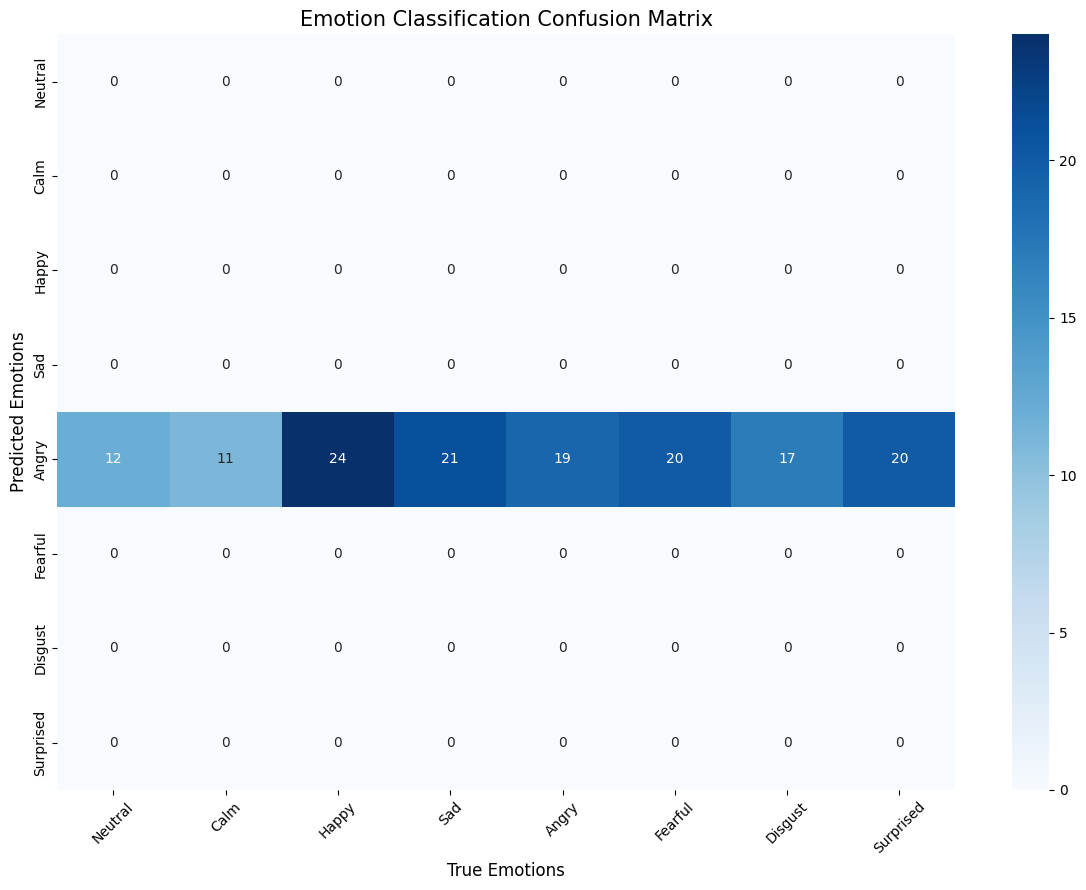

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the labels (RAVDESS standard 8 emotions)
emotion_labels = [
    "Neutral", "Calm", "Happy", "Sad", 
    "Angry", "Fearful", "Disgust", "Surprised"
]

# 2. Setup the plot
plt.figure(figsize=(12, 9))

# 3. Create the heatmap
# 'annot=True' shows the numbers in the cells
# 'fmt="g"' ensures numbers don't use scientific notation
# 'cmap="Blues"' provides a clear blue gradient
sns.heatmap(coff_mat, annot=True, fmt='g', cmap='Blues', 
            xticklabels=emotion_labels, 
            yticklabels=emotion_labels)

# 4. Label the axes based on your specific implementation
plt.xlabel('True Emotions', fontsize=12)
plt.ylabel('Predicted Emotions', fontsize=12)
plt.title('Emotion Classification Confusion Matrix', fontsize=15)

# 5. Clean up layout and display
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It is obivious as the inputs (text) not much based on emotions 

I have tried both here, and mostly both give same accuracies.

## Option A: 

In [39]:
class FusionNN(torch.nn.Module):
    def __init__(self,VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM):
        super().__init__()
        self.model1 = AudioCNN()
        self.model2 = EmotionRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)

        self.model3 = torch.nn.Sequential(
            torch.nn.Linear(8+8,16),
            torch.nn.ReLU(),
            torch.nn.Linear(16,8),
            torch.nn.ReLU(),
            torch.nn.Linear(8,8)
        )

    def forward(self,x,y):
        x1 = self.model1(x)
        y1 = self.model2(y)
        x2 = torch.concat((x1,y1),axis=1)
        return self.model3(x2)
        

In [40]:
class FusedDataset(Dataset):
    def __init__(self,audio_files,labels,texts):
        self.cnndata = RAVDESSDataset(audio_files,labels)
        self.rnndata = preprocess_text(texts)

    def __len__(self):
        return len(self.cnndata)

    def __getitem__(self,i):
        return self.cnndata[i],self.rnndata[i]

In [41]:
true_labels = list(torch.argmax(torch.Tensor(dataset.label),axis=1)+1)
fdataset = FusedDataset(audio_spectro.copy(),true_labels.copy(),statements_whisper.copy())

print(len(fdataset))

testing_set_frac = 0.2
valid_set_frac = 0.1

test_size = int(len(fdataset)*testing_set_frac) 
valid_size = int(len(fdataset)*valid_set_frac) 

train_size = len(fdataset) - test_size - valid_size

train_dataset,valid_dataset, test_dataset = random_split(fdataset, [train_size,valid_size, test_size],generator=torch.Generator().manual_seed(42))

1440


In [58]:
train_data = DataLoader(train_dataset,64)
valid_data = DataLoader(valid_dataset,64)

In [59]:
import time

# Hyperparameters
VOCAB_SIZE = tokenizer.vocab_size
EMBED_DIM = 300   # Standard for GloVe
HIDDEN_DIM = 64
OUTPUT_DIM = 8     # e.g., happy, sad, angry, fear, surprise, neutral
epoches = 70
# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FusionNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)

optimiser = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.1)
lossfn = nn.CrossEntropyLoss()

# Dummy training step
model.train()


training_loss = []
accuracies = []
taccuracies = []
start = time.time()
for i in range(epoches):
    model.train()
    correct = 0
    loss_val = 0
    for batch, ((X,y), Y) in enumerate(train_data):
        X = X.to(device)
        Y = Y.to(device)
        y = y.to(device)
        pred = model(X,Y)
        loss = lossfn(pred,y)
        loss.backward()
        loss_val += loss.item()*batch_size/train_size
        optimiser.step()
        preds = pred.argmax(dim=1)
        y = y.to("cpu")
        preds = preds.to("cpu")
        labels = y.argmax(dim=1)
        optimiser.zero_grad()
        correct += (preds == labels).sum().item()
        

        X = X.to("cpu")
        Y = Y.to("cpu")
    taccuracy = 100*correct/train_size
    taccuracies.append(taccuracy)
    correct = 0
    with torch.no_grad():
            for (X,y), Y in valid_data:
                X = X.to(device)
                Y = Y.to(device)
                outputs = model(X,Y)
                pred = torch.softmax(outputs, dim=1)
                
                preds = outputs.argmax(dim=1)
                preds = preds.to("cpu")
                labels = y.argmax(dim=1)

                X = X.to("cpu")
                Y = Y.to("cpu")
        
                correct += (preds == labels).sum().item()
    training_loss.append(loss_val)
    
    accuracy = 100*correct/valid_size
    accuracies.append(accuracy)
    if i%epoch_int == 0: 
        print(f"Epoch {i+1} training loss :{training_loss[-1]:9f} training accuracy = {taccuracy} valid accuracy = {accuracy}")
        print(time.time()-start,"s")

Epoch 1 training loss : 4.183624 training accuracy = 14.781746031746032 valid accuracy = 18.055555555555557
0.5691094398498535 s
Epoch 11 training loss : 2.811724 training accuracy = 45.535714285714285 valid accuracy = 41.666666666666664
6.169660568237305 s
Epoch 21 training loss : 2.064396 training accuracy = 61.01190476190476 valid accuracy = 52.77777777777778
11.795109987258911 s
Epoch 31 training loss : 1.620532 training accuracy = 69.94047619047619 valid accuracy = 53.47222222222222
17.533178091049194 s
Epoch 41 training loss : 1.148915 training accuracy = 79.26587301587301 valid accuracy = 58.333333333333336
23.121391534805298 s
Epoch 51 training loss : 0.908493 training accuracy = 83.43253968253968 valid accuracy = 56.25
28.77165961265564 s
Epoch 61 training loss : 0.656386 training accuracy = 89.68253968253968 valid accuracy = 59.02777777777778
34.40005373954773 s


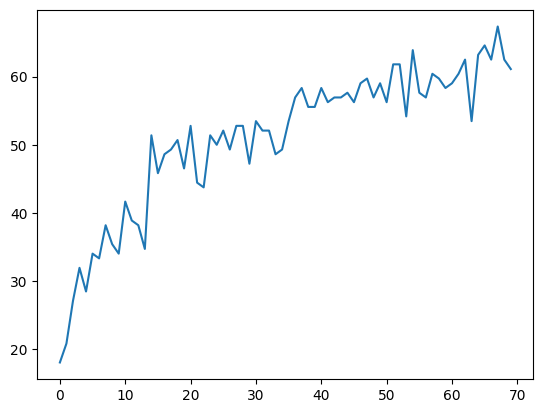

In [60]:
plt.plot(accuracies)

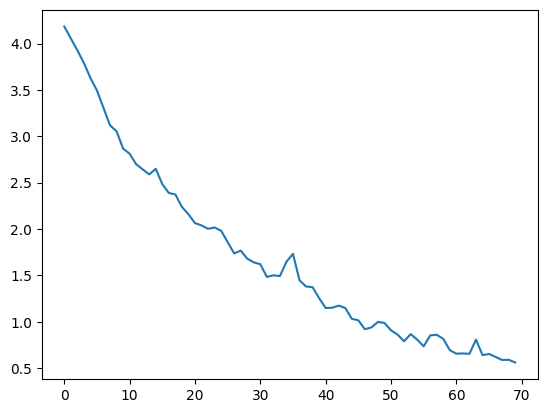

In [61]:
plt.plot(training_loss)

In [62]:
test_data = DataLoader(test_dataset,20)

In [63]:
model.to(device)
model.eval()
correct = 0
loss_val = 0
accuracies = []
coff_mat = np.zeros((8,8))

for (X,y), Y in test_data:
        X = X.to(device)
        Y = Y.to(device)
        outputs = model(X,Y)
        pred = torch.softmax(outputs, dim=1)
                
        preds = pred.argmax(dim=1)
        preds = preds.to("cpu")
        labels = y.argmax(dim=1)
        for i in range(len(preds)):
            coff_mat[preds[i],labels[i]]+=1

        X = X.to("cpu")
        Y = Y.to("cpu")
        
        correct += (preds == labels).sum().item()
    
        accuracy = 100*correct/test_size
        accuracies.append(accuracy)
        print(accuracy)

3.4722222222222223
7.291666666666667
10.76388888888889
13.88888888888889
18.055555555555557
21.180555555555557
24.65277777777778
28.819444444444443
33.333333333333336
37.84722222222222
42.708333333333336
47.22222222222222
51.388888888888886
54.861111111111114
56.59722222222222


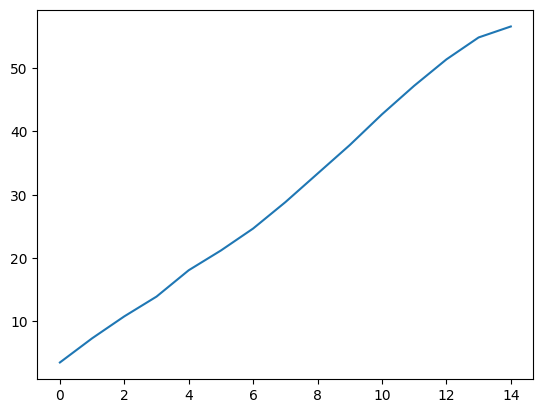

In [64]:
plt.plot(accuracies)

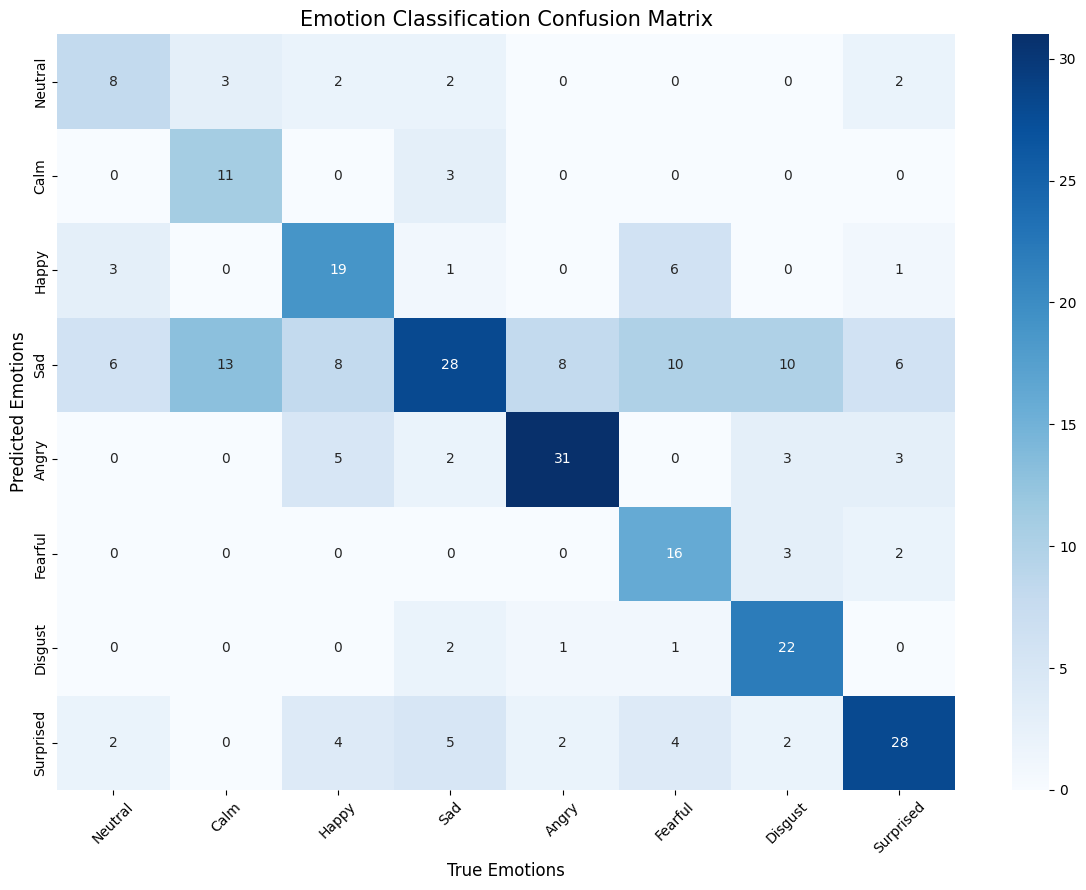

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the labels (RAVDESS standard 8 emotions)
emotion_labels = [
    "Neutral", "Calm", "Happy", "Sad", 
    "Angry", "Fearful", "Disgust", "Surprised"
]

# 2. Setup the plot
plt.figure(figsize=(12, 9))

# 3. Create the heatmap
# 'annot=True' shows the numbers in the cells
# 'fmt="g"' ensures numbers don't use scientific notation
# 'cmap="Blues"' provides a clear blue gradient
sns.heatmap(coff_mat, annot=True, fmt='g', cmap='Blues', 
            xticklabels=emotion_labels, 
            yticklabels=emotion_labels)

# 4. Label the axes based on your specific implementation
plt.xlabel('True Emotions', fontsize=12)
plt.ylabel('Predicted Emotions', fontsize=12)
plt.title('Emotion Classification Confusion Matrix', fontsize=15)

# 5. Clean up layout and display
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It seems that low energy emotions are mixed up

In [50]:
model.to("cpu")

tp = np.diag(coff_mat)
fp = np.sum(coff_mat, axis=1) - tp  # Sum along rows
fn = np.sum(coff_mat, axis=0) - tp  # Sum along columns

# 2. Calculate metrics (adding a tiny epsilon to avoid division by zero)
epsilon = 1e-7
precision = tp / (tp + fp + epsilon)
recall = tp / (tp + fn + epsilon)
f1 = 2 * (precision * recall) / (precision + recall + epsilon)

# 3. Calculate Averages
macro_f1 = np.mean(f1)
accuracy = np.sum(tp) / np.sum(coff_mat)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Display per-class results
emotion_labels = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]
for i, label in enumerate(emotion_labels):
    print(f"{label}: Precision: {precision[i]:.2f} Recall: {recall[i]:.2f} F1: {f1[i]:.2f}")

Accuracy: 0.5139
Macro F1-Score: 0.5066
Neutral: Precision: 0.37 Recall: 0.32 F1: 0.34
Calm: Precision: 0.76 Recall: 0.48 F1: 0.59
Happy: Precision: 0.32 Recall: 0.53 F1: 0.40
Sad: Precision: 0.42 Recall: 0.37 F1: 0.40
Angry: Precision: 0.79 Recall: 0.55 F1: 0.65
Fearful: Precision: 0.42 Recall: 0.35 F1: 0.38
Disgust: Precision: 0.67 Recall: 0.67 F1: 0.67
Surprised: Precision: 0.55 Recall: 0.71 F1: 0.62


## Option B: 

In [51]:
CNN_model.eval()
RNNmodel.eval()
CNN_model = CNN_model.to(device)
RNNmodel = RNNmodel.to(device)
correct1 = 0
correct2 = 0
accuracies1 = []
accuracies2 = []
coff_mat1 = np.zeros((8,8))
coff_mat2 = np.zeros((8,8))

for (X,y), Y in test_data:
        X = X.to(device)
        Y = Y.to(device)
        out1 = CNN_model(X)
        out2 = RNNmodel(Y)
        pred1 = torch.softmax(out1, dim=1)*0.5 + torch.softmax(out2, dim=1)*0.5
        pred2 = torch.softmax(out1, dim=1)*0.7 + torch.softmax(out2, dim=1)*0.3
                
        pred1 = pred1.argmax(dim=1).to("cpu")
        pred2 = pred2.argmax(dim=1).to("cpu")
        labels = y.argmax(dim=1)
        for i in range(len(pred1)):
            coff_mat1[pred1[i],labels[i]]+=1    
        for i in range(len(pred2)):
            coff_mat2[pred2[i],labels[i]]+=1

        X = X.to("cpu")
        Y = Y.to("cpu")
        
        correct1 += (pred1 == labels).sum().item()
        correct2 += (pred2 == labels).sum().item()
    
        accuracy1 = 100*correct1/test_size
        accuracy2 = 100*correct2/test_size
        accuracies1.append(accuracy1)
        accuracies2.append(accuracy2)

58.68055555555556

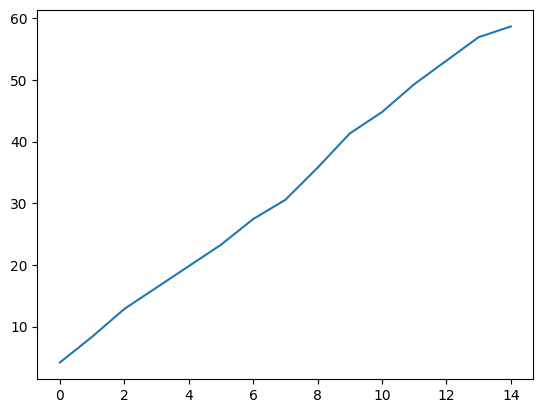

In [52]:
plt.plot(accuracies1)
accuracies1[-1]

58.68055555555556

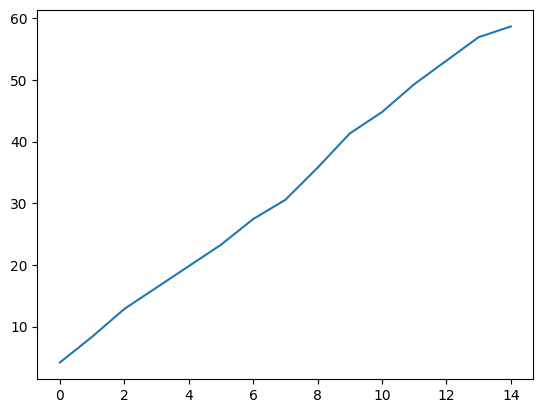

In [53]:
plt.plot(accuracies2)
accuracies2[-1]

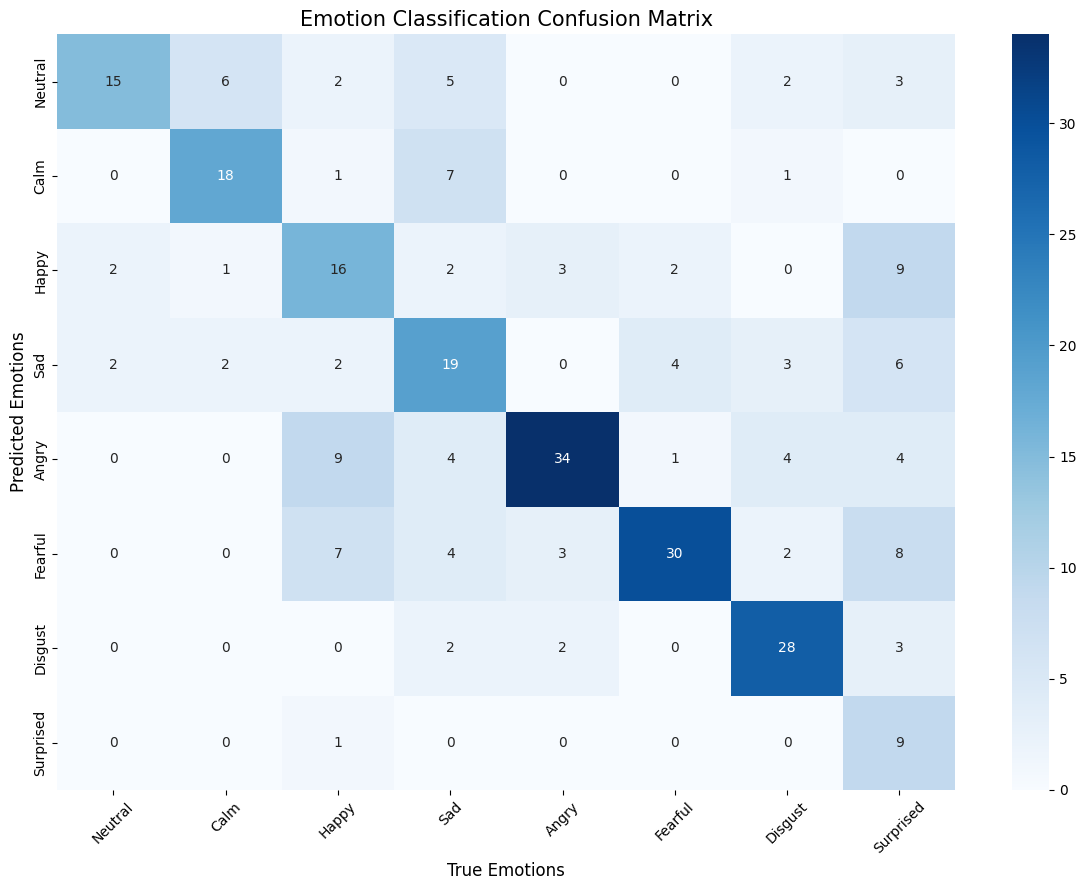

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the labels (RAVDESS standard 8 emotions)
emotion_labels = [
    "Neutral", "Calm", "Happy", "Sad", 
    "Angry", "Fearful", "Disgust", "Surprised"
]

# 2. Setup the plot
plt.figure(figsize=(12, 9))

# 3. Create the heatmap
# 'annot=True' shows the numbers in the cells
# 'fmt="g"' ensures numbers don't use scientific notation
# 'cmap="Blues"' provides a clear blue gradient
sns.heatmap(coff_mat1, annot=True, fmt='g', cmap='Blues', 
            xticklabels=emotion_labels, 
            yticklabels=emotion_labels)

# 4. Label the axes based on your specific implementation
plt.xlabel('True Emotions', fontsize=12)
plt.ylabel('Predicted Emotions', fontsize=12)
plt.title('Emotion Classification Confusion Matrix', fontsize=15)

# 5. Clean up layout and display
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 carries the trait of audio model

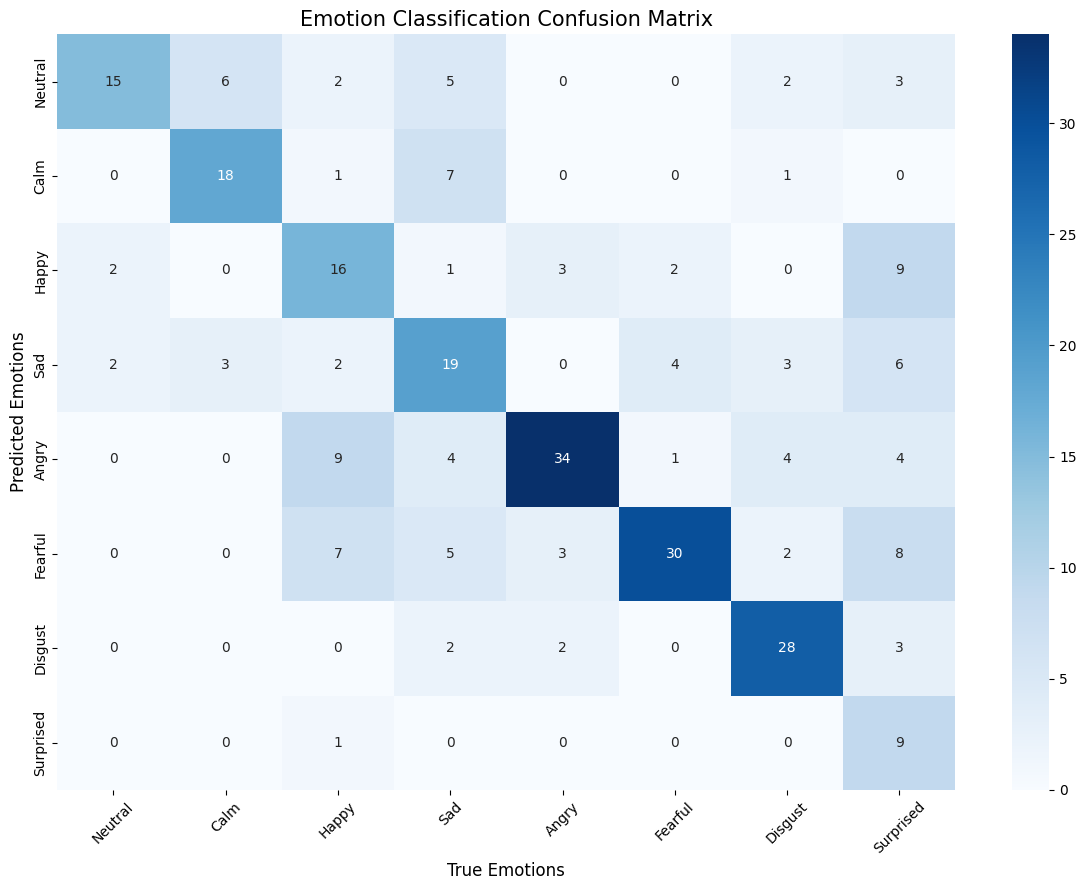

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the labels (RAVDESS standard 8 emotions)
emotion_labels = [
    "Neutral", "Calm", "Happy", "Sad", 
    "Angry", "Fearful", "Disgust", "Surprised"
]

# 2. Setup the plot
plt.figure(figsize=(12, 9))

# 3. Create the heatmap
# 'annot=True' shows the numbers in the cells
# 'fmt="g"' ensures numbers don't use scientific notation
# 'cmap="Blues"' provides a clear blue gradient
sns.heatmap(coff_mat2, annot=True, fmt='g', cmap='Blues', 
            xticklabels=emotion_labels, 
            yticklabels=emotion_labels)

# 4. Label the axes based on your specific implementation
plt.xlabel('True Emotions', fontsize=12)
plt.ylabel('Predicted Emotions', fontsize=12)
plt.title('Emotion Classification Confusion Matrix', fontsize=15)

# 5. Clean up layout and display
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Same here too

In [56]:
coff_mat = coff_mat1

tp = np.diag(coff_mat)
fp = np.sum(coff_mat, axis=1) - tp  # Sum along rows
fn = np.sum(coff_mat, axis=0) - tp  # Sum along columns

# 2. Calculate metrics (adding a tiny epsilon to avoid division by zero)
epsilon = 1e-7
precision = tp / (tp + fp + epsilon)
recall = tp / (tp + fn + epsilon)
f1 = 2 * (precision * recall) / (precision + recall + epsilon)

# 3. Calculate Averages
macro_f1 = np.mean(f1)
accuracy = np.sum(tp) / np.sum(coff_mat)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Display per-class results
emotion_labels = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]
for i, label in enumerate(emotion_labels):
    print(f"{label}: Precision: {precision[i]:.2f} Recall: {recall[i]:.2f} F1: {f1[i]:.2f}")

Accuracy: 0.5868
Macro F1-Score: 0.5746
Neutral: Precision: 0.45 Recall: 0.79 F1: 0.58
Calm: Precision: 0.67 Recall: 0.67 F1: 0.67
Happy: Precision: 0.46 Recall: 0.42 F1: 0.44
Sad: Precision: 0.50 Recall: 0.44 F1: 0.47
Angry: Precision: 0.61 Recall: 0.81 F1: 0.69
Fearful: Precision: 0.56 Recall: 0.81 F1: 0.66
Disgust: Precision: 0.80 Recall: 0.70 F1: 0.75
Surprised: Precision: 0.90 Recall: 0.21 F1: 0.35


In [57]:
coff_mat = coff_mat2

tp = np.diag(coff_mat)
fp = np.sum(coff_mat, axis=1) - tp  # Sum along rows
fn = np.sum(coff_mat, axis=0) - tp  # Sum along columns

# 2. Calculate metrics (adding a tiny epsilon to avoid division by zero)
epsilon = 1e-7
precision = tp / (tp + fp + epsilon)
recall = tp / (tp + fn + epsilon)
f1 = 2 * (precision * recall) / (precision + recall + epsilon)

# 3. Calculate Averages
macro_f1 = np.mean(f1)
accuracy = np.sum(tp) / np.sum(coff_mat)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Display per-class results
emotion_labels = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]
for i, label in enumerate(emotion_labels):
    print(f"{label}: Precision: {precision[i]:.2f} Recall: {recall[i]:.2f} F1: {f1[i]:.2f}")

Accuracy: 0.5868
Macro F1-Score: 0.5746
Neutral: Precision: 0.45 Recall: 0.79 F1: 0.58
Calm: Precision: 0.67 Recall: 0.67 F1: 0.67
Happy: Precision: 0.48 Recall: 0.42 F1: 0.45
Sad: Precision: 0.49 Recall: 0.44 F1: 0.46
Angry: Precision: 0.61 Recall: 0.81 F1: 0.69
Fearful: Precision: 0.55 Recall: 0.81 F1: 0.65
Disgust: Precision: 0.80 Recall: 0.70 F1: 0.75
Surprised: Precision: 0.90 Recall: 0.21 F1: 0.35
